# Cloud Server Resource Consumption (Supervised Learning - Regression)

*Analyze server workload and system activity to predict resource consumption and optimize infrastructure usage.*

## Step 1:Import Libraries

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2:Load the Dataset

In [2]:
df=pd.read_csv("C:\\Users\\Neha\\Downloads\\cloud_server_resource_consumption_dataset.csv")

In [3]:
df.head()

,hour_of_day,day_of_week,is_weekend,is_peak_hour,active_users,requests_per_minute,avg_request_size_kb,api_calls_per_minute,db_queries_per_minute,background_jobs_count,...,network_in_mbps,network_out_mbps,disk_read_ops,disk_write_ops,avg_response_time_ms,error_rate_percent,scheduled_job_flag,release_day_flag,cpu_usage_percent,memory_usage_percent
0,6,0,0,0,3040,3528.593163,75.849039,786.849818,406.162846,2,...,36.268301,39.274311,251.509904,392.211125,88.905252,0.618693,0,0,78.908966,83.630484
1,19,1,0,1,4693,3758.887203,95.257798,1056.615844,775.439918,1,...,54.797336,48.349988,1124.970299,343.155215,95.084826,0.533934,0,0,87.715187,65.732609
2,14,5,1,0,1199,1476.103998,66.247144,383.402379,381.597154,3,...,25.665953,23.270123,411.107454,170.836419,57.639430,2.095670,0,0,42.231409,55.649199
3,10,6,1,0,112,167.792816,73.781887,33.884015,28.714088,3,...,1.579843,1.677699,42.820615,18.561441,70.405772,0.792096,0,0,14.467778,43.019040
4,7,1,0,0,4989,5010.979711,6.535530,2083.248968,751.336847,1,...,34.891989,35.135482,665.132626,593.126019,113.564119,1.790406,0,0,96.595032,54.872855


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   hour_of_day             10000 non-null  int64  
 1   day_of_week             10000 non-null  int64  
 2   is_weekend              10000 non-null  int64  
 3   is_peak_hour            10000 non-null  int64  
 4   active_users            10000 non-null  int64  
 5   requests_per_minute     10000 non-null  float64
 6   avg_request_size_kb     10000 non-null  float64
 7   api_calls_per_minute    10000 non-null  float64
 8   db_queries_per_minute   10000 non-null  float64
 9   background_jobs_count   10000 non-null  int64  
 10  cache_hit_ratio         10000 non-null  float64
 11  allocated_cpu_cores     10000 non-null  int64  
 12  allocated_memory_gb     10000 non-null  float64
 13  container_count         10000 non-null  int64  
 14  running_services_count  10000 non-null 

In [5]:
df.isnull().sum()

hour_of_day               0
day_of_week               0
is_weekend                0
is_peak_hour              0
active_users              0
requests_per_minute       0
avg_request_size_kb       0
api_calls_per_minute      0
db_queries_per_minute     0
background_jobs_count     0
cache_hit_ratio           0
allocated_cpu_cores       0
allocated_memory_gb       0
container_count           0
running_services_count    0
network_in_mbps           0
network_out_mbps          0
disk_read_ops             0
disk_write_ops            0
avg_response_time_ms      0
error_rate_percent        0
scheduled_job_flag        0
release_day_flag          0
cpu_usage_percent         0
memory_usage_percent      0
dtype: int64

## Step 3:Exploratory Data Analysis (EDA)

# 1. What is the distribution of CPU usage?

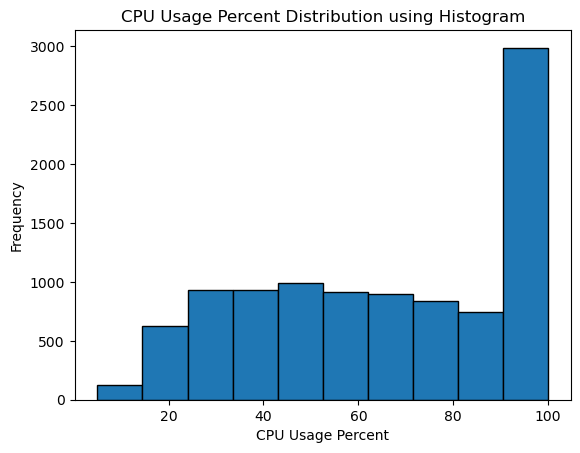

In [10]:
plt.hist(df["cpu_usage_percent"],edgecolor='Black')
plt.title("CPU Usage Percent Distribution using Histogram")
plt.xlabel("CPU Usage Percent")
plt.ylabel("Frequency")
plt.show()

- **The histogram shows most observations appear in the higher CPU usage range (around 80%–100%)** 
- **Moderate CPU usage levels (around 40%–70%) also occur but are less frequent compared to the highest range.**

# 2. What is the distribution of memory usage?


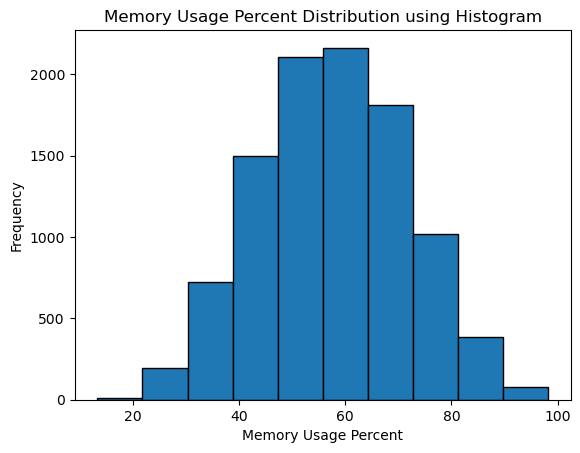

In [11]:
plt.hist(df["memory_usage_percent"],edgecolor='Black')
plt.title("Memory Usage Percent Distribution using Histogram")
plt.xlabel("Memory Usage Percent")
plt.ylabel("Frequency")
plt.show()

- **The Histogram shows that most of the observations are appear in the higher memory usage range(around 50% to 60%).**
- **Moderate CPU usage levels(around 60% to 70%) are also occurs but less frequent compared to highest range**

# 3. How many observations exist for each hour of day?

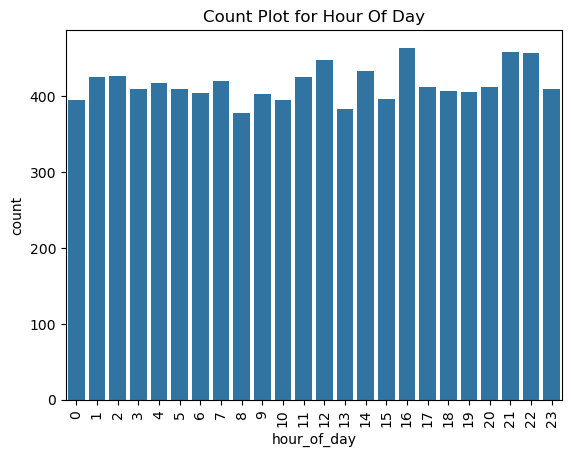

In [79]:
sns.countplot(x=df["hour_of_day"],data=df)
plt.title("Count Plot for Hour Of Day")
plt.xticks(rotation=90)
plt.show()

- **The countplot shows that most the observations are appear in 16 and 21 are the highest hour of the day**

# 4.Which hours show the highest traffic ?

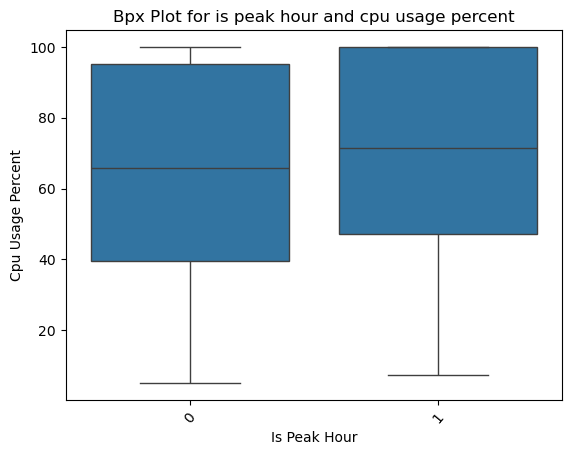

In [13]:
sns.boxplot(x="is_peak_hour",y="cpu_usage_percent",data=df)
plt.title("Box Plot for is peak hour and cpu usage percent")
plt.xlabel("Is Peak Hour")
plt.ylabel("Cpu Usage Percent")
plt.xticks(rotation=50)
plt.show()

- **The boxplot shows that is peak hour 0 have the same median sale and 1 have the higher median sale**
- **and its frequency is in between 40% to 100%**

# 5. Do peak hours significantly increase CPU usage?

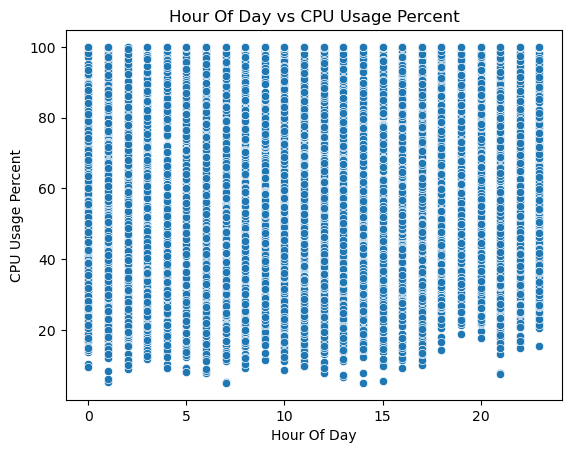

In [14]:
sns.scatterplot(x='hour_of_day', y='cpu_usage_percent', data=df)
plt.title("Hour Of Day vs CPU Usage Percent")
plt.xlabel("Hour Of Day")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between hour of day and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 6.Does the number of active users affect CPU utilization?

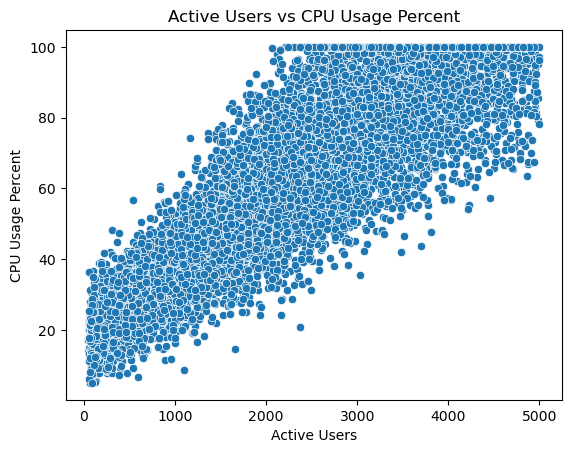

In [15]:
sns.scatterplot(x='active_users', y='cpu_usage_percent', data=df)
plt.title("Active Users vs CPU Usage Percent")
plt.xlabel("Active Users")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between active users and cpu usage percent.**
- **It shows the clear positive relationship between this features as the active users increases cpu usage percent also increases.**

# 7. How strongly are requests per minute correlated with CPU usage?

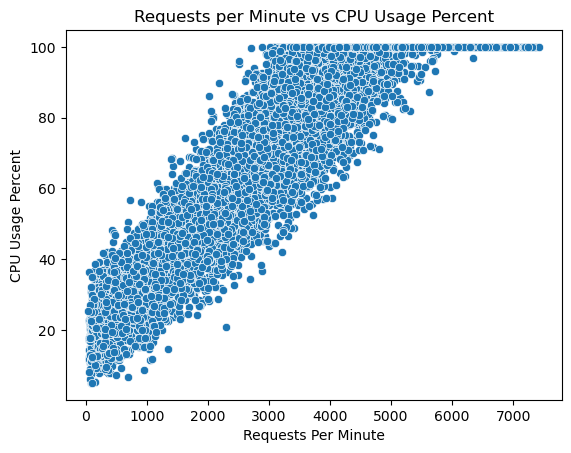

In [16]:
sns.scatterplot(x='requests_per_minute', y='cpu_usage_percent', data=df)
plt.title("Requests per Minute vs CPU Usage Percent")
plt.xlabel("Requests Per Minute")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between requeests per minute and cpu usage percent.**
- **It shows the clear positive relationship between this features as the requests per minute increases cpu usage percent also increases.**

# 8. Does request size influence CPU load?

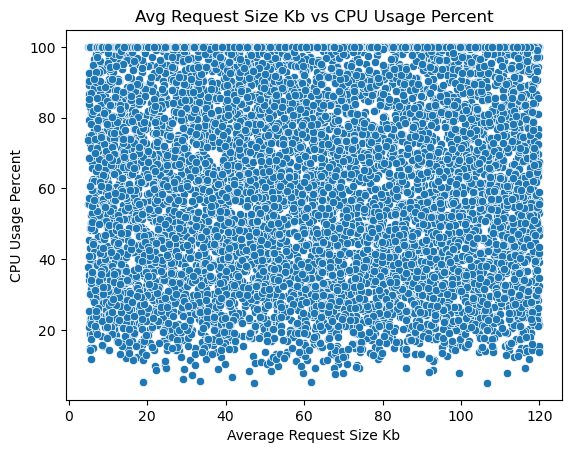

In [95]:
sns.scatterplot(x='avg_request_size_kb', y='cpu_usage_percent', data=df)
plt.title("Avg Request Size Kb vs CPU Usage Percent")
plt.xlabel("Average Request Size Kb")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between average request size and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 9.Is there a relationship between API calls and CPU consumption?

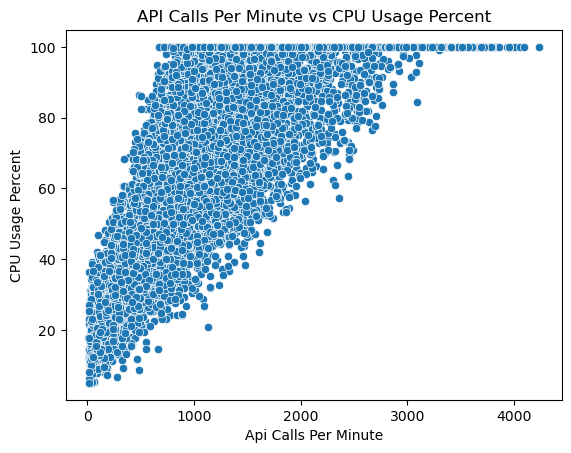

In [18]:
sns.scatterplot(x='api_calls_per_minute', y='cpu_usage_percent', data=df)
plt.title("API Calls Per Minute vs CPU Usage Percent")
plt.xlabel("Api Calls Per Minute")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between api calls per minute and cpu usage percent.**
- **It shows the clear positive relationship between this features as the api calls per minute increases cpu usage percent also increases.**

# 10.Do database queries significantly impact CPU usage?

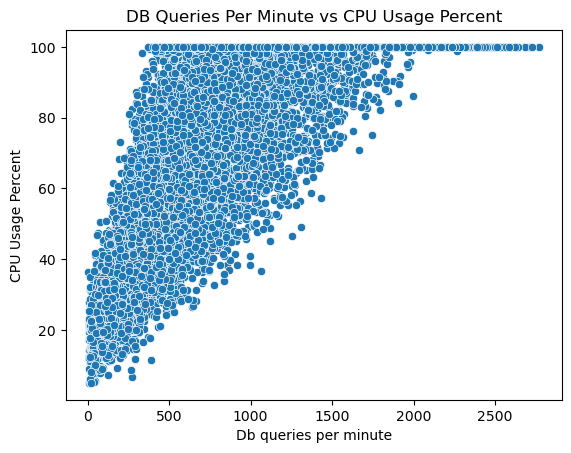

In [19]:
sns.scatterplot(x='db_queries_per_minute', y='cpu_usage_percent', data=df)
plt.title("DB Queries Per Minute vs CPU Usage Percent")
plt.xlabel("Db queries per minute")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between db queries per minute and cpu usage percent.**
- **It shows the clear positive relationship between this features as the db queries per minute increases cpu usage percent also increases.**

# 11. How does background job count affect CPU usage?

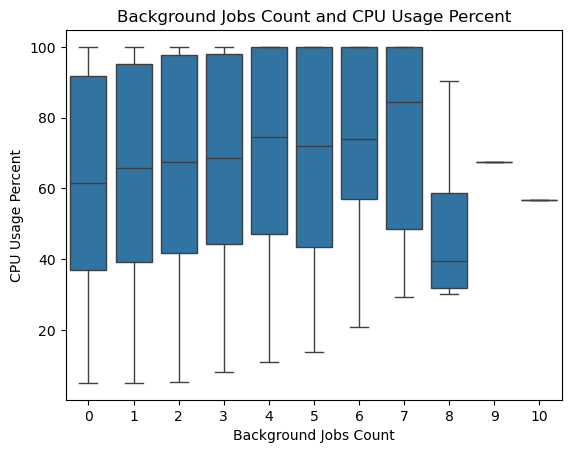

In [121]:
sns.boxplot(x='background_jobs_count', y='cpu_usage_percent', data=df)
plt.title("Background Jobs Count and CPU Usage Percent")
plt.xlabel("Background Jobs Count")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The boxplot summarizes that the distribution of background jobs count and cpu usage percent.**
- **It shows hos the cpu usage percent changes when the background jobs count increases.**
- **As the background_jobs_count increases from 0 to around 6–7, the median CPU usage generally increases, 
indicating that more background jobs contribute to higher CPU load.**
- **For very high job counts (8–10), CPU usage appears more inconsistent, possibly due to fewer observations or system limits.**

# 12.Does cache hit ratio reduce server load?

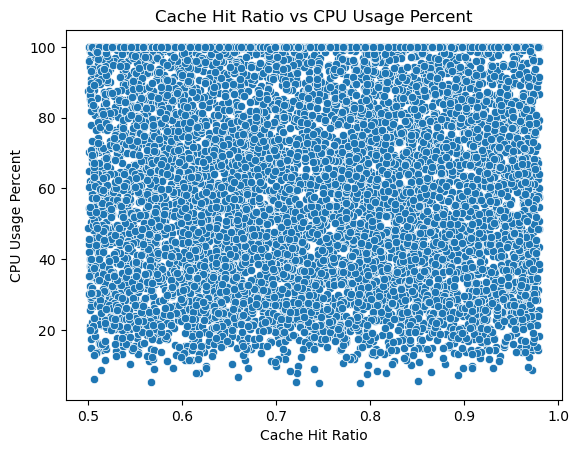

In [21]:
sns.scatterplot(x='cache_hit_ratio', y='cpu_usage_percent', data=df)
plt.title("Cache Hit Ratio vs CPU Usage Percent")
plt.xlabel("Cache Hit Ratio")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between cache hit ratio and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 13.Are there differences in CPU load between weekdays and weekends?

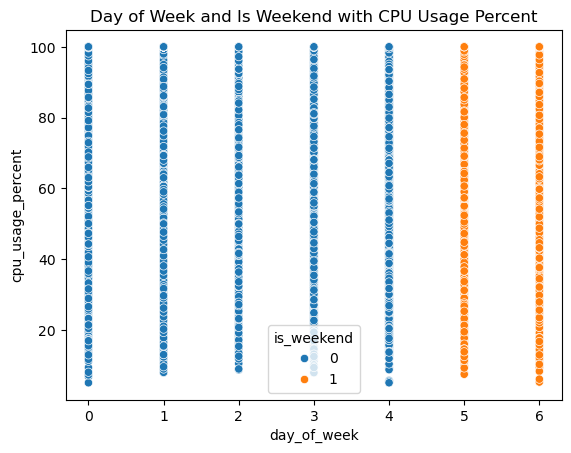

In [63]:
sns.scatterplot(x='day_of_week', y='cpu_usage_percent',hue="is_weekend", data=df)
plt.title("Day of Week and Is Weekend with CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between day of week ,is weekend and cpu usage percent.**
- **It shows clear no relationship between these features.**

# 14.How does network traffic influence CPU consumption?

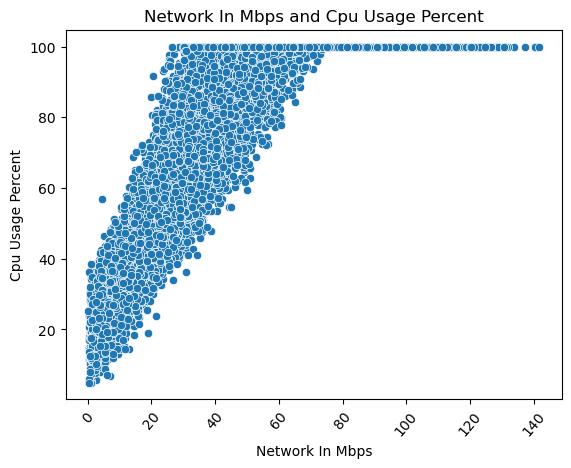

In [23]:
sns.scatterplot(x="network_in_mbps",y="cpu_usage_percent",data=df)
plt.title("Network In Mbps and Cpu Usage Percent")
plt.xlabel("Network In Mbps")
plt.ylabel("Cpu Usage Percent")
plt.xticks(rotation=50)
plt.show()

- **The scatterplot shows the relationship between network in mbps and cpu usage percent.**
- **It shows the clear positive relationship between this features as the active users increases cpu usage percent also increases.**
- **When network in mbps are low (0 to 20) cpu usage percent mostly stays in the (0% to 40%).**
- **When the network in mbps are between (20 to 60) cpu usage percent stays in the (40% to 100%)** 
- **But as the network in mbps are between (60 to 80 )cpu usage percent is more less in the (100%).**

# 15.Does disk read activity affect CPU load?

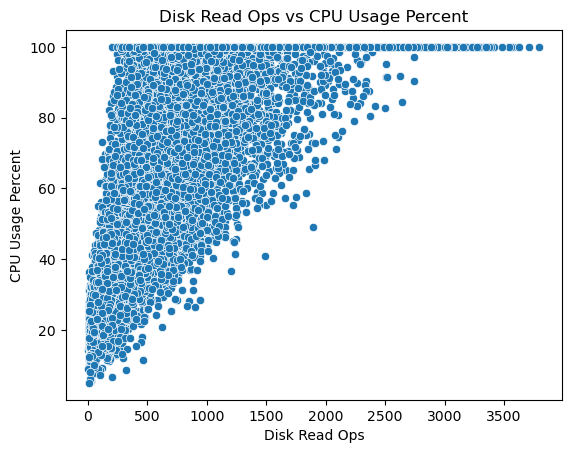

In [24]:
sns.scatterplot(x='disk_read_ops', y='cpu_usage_percent', data=df)
plt.title("Disk Read Ops vs CPU Usage Percent")
plt.xlabel("Disk Read Ops")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between disk read ops  and cpu usage percent.**
- **It shows the clear positive relationship between this features as the disk read ops increases cpu usage percent also increases.**
- **When disk read ops are low (0 to 500) cpu usage percent mostly stays in the (0% to 40%).**
- **When the disk read ops are between (1000 to 2000) cpu usage percent stays in the (40 % 100%)** 
- **But as the disk read ops are between (2000 to 3500)cpu usage percent is more less in the (100%).**

# 16 .Do disk write operations correlate with CPU usage?

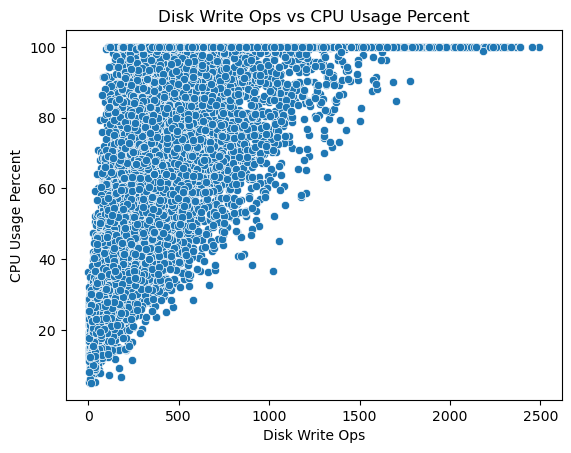

In [25]:
sns.scatterplot(x='disk_write_ops', y='cpu_usage_percent', data=df)
plt.title("Disk Write Ops vs CPU Usage Percent")
plt.xlabel("Disk Write Ops")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between disk write operations and cpu usage percent.**
- **It shows the clear positive relationship between this features as the disk write operations increases cpu usage percent also increases.**
- **When disk write operations are low (0 to 500) cpu usage percent mostly stays in the (0% to 40%).**
- **When the disk write operations are between (500 to 1500) cpu usage percent stays in the (40% to 100%)** 
- **But as the disk write operations are between (1500 to 2500)cpu usage percent is more less in the (100%).**

# 17.Is high response time associated with higher CPU usage?

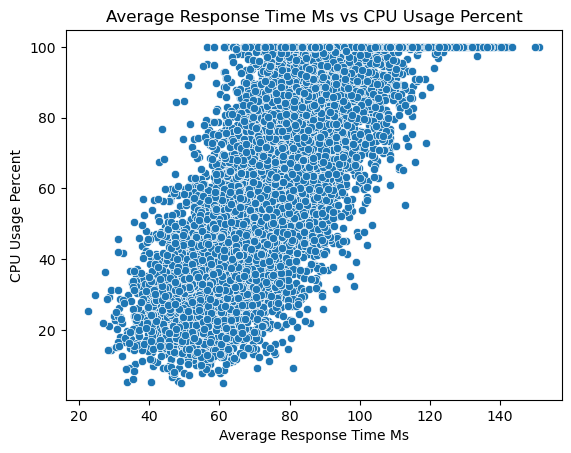

In [26]:
sns.scatterplot(x='avg_response_time_ms', y='cpu_usage_percent', data=df)
plt.title("Average Response Time Ms vs CPU Usage Percent")
plt.xlabel("Average Response Time Ms")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between average response time ms and cpu usage percent.**
- **It shows the clear positive relationship between this features as the average response time ms increases cpu usage percent also increases.**

# 18.Does higher error rate indicate server stress?

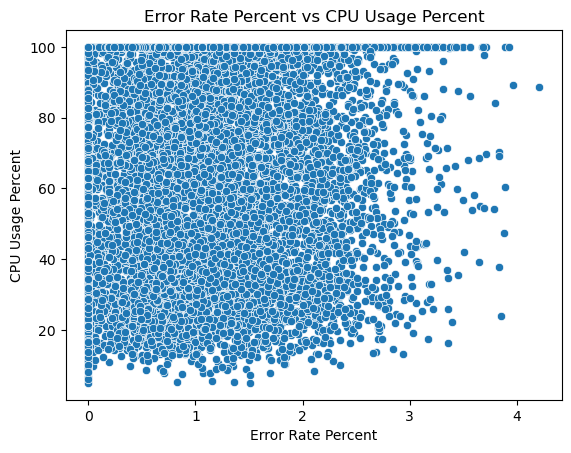

In [27]:
sns.scatterplot(x='error_rate_percent', y='cpu_usage_percent', data=df)
plt.title("Error Rate Percent vs CPU Usage Percent")
plt.xlabel("Error Rate Percent")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between error rate percent and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 19.Do release days cause spikes in CPU usage?

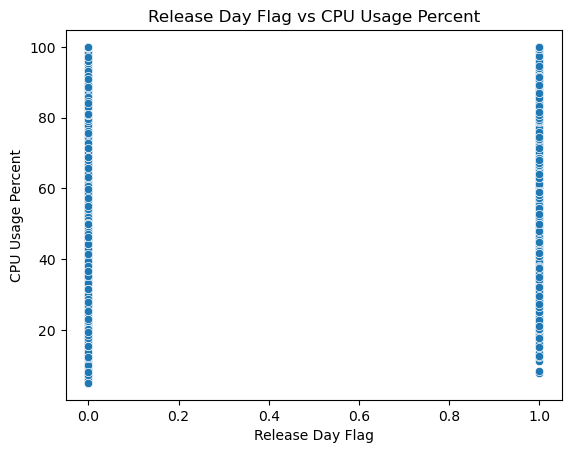

In [28]:
sns.scatterplot(x='release_day_flag', y='cpu_usage_percent', data=df)
plt.title("Release Day Flag vs CPU Usage Percent")
plt.xlabel("Release Day Flag")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between release day flag  and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 20.How does allocated CPU cores affect utilization levels?

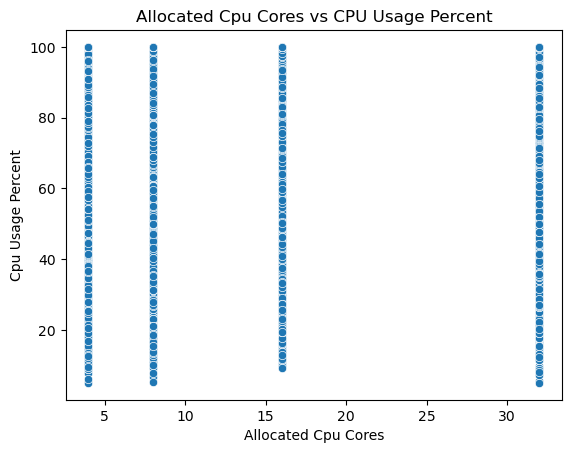

In [29]:
sns.scatterplot(x='allocated_cpu_cores', y='cpu_usage_percent', data=df)
plt.title("Allocated Cpu Cores vs CPU Usage Percent")
plt.xlabel("Allocated Cpu Cores")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between allocated cpu cores and cpu usage percent.**
- **It shows the clear positive relationship between this features.**

# 21.Does container count influence resource consumption?

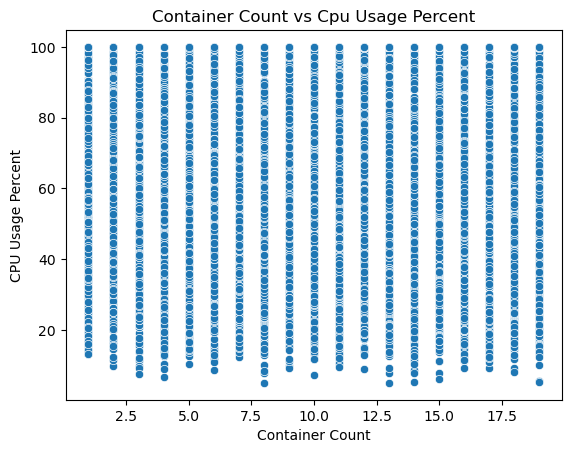

In [30]:
sns.scatterplot(x='container_count', y='cpu_usage_percent', data=df)
plt.title("Container Count vs Cpu Usage Percent")
plt.xlabel("Container Count")
plt.ylabel("CPU Usage Percent")
plt.show()

- **The scatterplot shows the relationship between container count and cpu usage percent.**
- **It shows the clear positive relationship between this features.**

# 22.Do more running services increase CPU load?

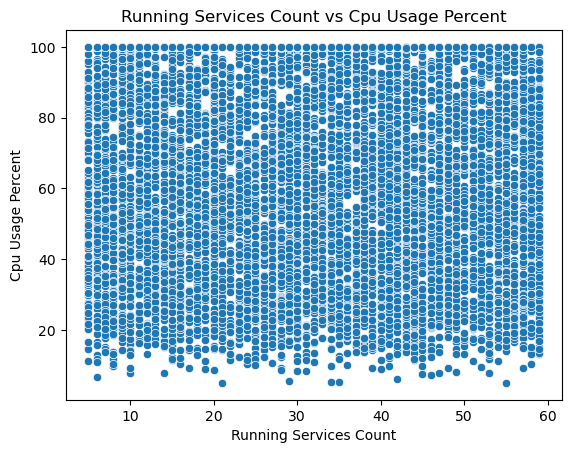

In [31]:
sns.scatterplot(x='running_services_count', y='cpu_usage_percent', data=df)
plt.title("Running Services Count vs Cpu Usage Percent")
plt.xlabel("Running Services Count")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between running services count and cpu usage percent.**
- **It shows the clear positive relationship between this features.**

# 23.What is the correlation matrix of all numerical features?

In [32]:
df.dtypes

hour_of_day                 int64
day_of_week                 int64
is_weekend                  int64
is_peak_hour                int64
active_users                int64
requests_per_minute       float64
avg_request_size_kb       float64
api_calls_per_minute      float64
db_queries_per_minute     float64
background_jobs_count       int64
cache_hit_ratio           float64
allocated_cpu_cores         int64
allocated_memory_gb       float64
container_count             int64
running_services_count      int64
network_in_mbps           float64
network_out_mbps          float64
disk_read_ops             float64
disk_write_ops            float64
avg_response_time_ms      float64
error_rate_percent        float64
scheduled_job_flag          int64
release_day_flag            int64
cpu_usage_percent         float64
memory_usage_percent      float64
dtype: object

In [33]:
numerical_col=df.select_dtypes(include=['int64','float64'])

In [34]:
corr=numerical_col.corr()

In [35]:
corr

,hour_of_day,day_of_week,is_weekend,is_peak_hour,active_users,requests_per_minute,avg_request_size_kb,api_calls_per_minute,db_queries_per_minute,background_jobs_count,...,network_in_mbps,network_out_mbps,disk_read_ops,disk_write_ops,avg_response_time_ms,error_rate_percent,scheduled_job_flag,release_day_flag,cpu_usage_percent,memory_usage_percent
hour_of_day,1.000000,0.003113,0.005598,0.752021,-0.019200,-0.020220,-0.016680,-0.020667,-0.007343,0.005300,...,-0.023146,-0.026586,-0.009851,-0.009193,-0.019891,0.004209,0.004334,-0.014476,0.049134,0.009055
day_of_week,0.003113,1.000000,0.790009,0.005381,-0.015762,-0.011829,-0.015576,-0.010392,-0.015295,0.022993,...,-0.008712,-0.010507,-0.022408,-0.013967,-0.010053,0.002287,0.017240,0.009600,-0.015293,0.004703
is_weekend,0.005598,0.790009,1.000000,0.001085,-0.006248,-0.002297,-0.011601,-0.006936,-0.008155,0.022867,...,-0.002390,-0.001325,-0.011134,-0.005728,-0.001709,-0.005466,0.016435,0.015175,-0.008449,0.004911
is_peak_hour,0.752021,0.005381,0.001085,1.000000,-0.012840,-0.012941,-0.019571,-0.019280,-0.003359,0.007854,...,-0.008333,-0.011766,-0.002974,-0.002129,-0.018473,-0.001625,0.008876,-0.003729,0.081923,0.008934
active_users,-0.019200,-0.015762,-0.006248,-0.012840,1.000000,0.942174,-0.001925,0.824482,0.778539,0.010510,...,0.781549,0.767306,0.698909,0.653117,0.815757,0.036724,0.010458,-0.013646,0.899578,0.327689
requests_per_minute,-0.020220,-0.011829,-0.002297,-0.012941,0.942174,1.000000,0.000968,0.874734,0.831511,0.014942,...,0.831079,0.816961,0.749538,0.700661,0.866135,0.043125,0.017178,-0.010521,0.919786,0.310723
avg_request_size_kb,-0.016680,-0.015576,-0.011601,-0.019571,-0.001925,0.000968,1.000000,-0.002990,0.002809,0.007092,...,-0.006213,-0.005433,0.003284,-0.003034,0.003364,-0.003328,-0.003894,0.007202,-0.001616,0.002557
api_calls_per_minute,-0.020667,-0.010392,-0.006936,-0.019280,0.824482,0.874734,-0.002990,1.000000,0.722692,0.010222,...,0.728811,0.713714,0.653573,0.608837,0.760378,0.039429,0.008551,-0.012594,0.802896,0.269107
db_queries_per_minute,-0.007343,-0.015295,-0.008155,-0.003359,0.778539,0.831511,0.002809,0.722692,1.000000,0.010207,...,0.692260,0.680480,0.896482,0.842807,0.718152,0.035542,0.011374,-0.011367,0.771569,0.257525
background_jobs_count,0.005300,0.022993,0.022867,0.007854,0.010510,0.014942,0.007092,0.010222,0.010207,1.000000,...,0.006631,0.006765,0.011694,0.009116,0.013982,0.014198,0.731711,-0.014667,0.085877,0.004688


<Axes: >

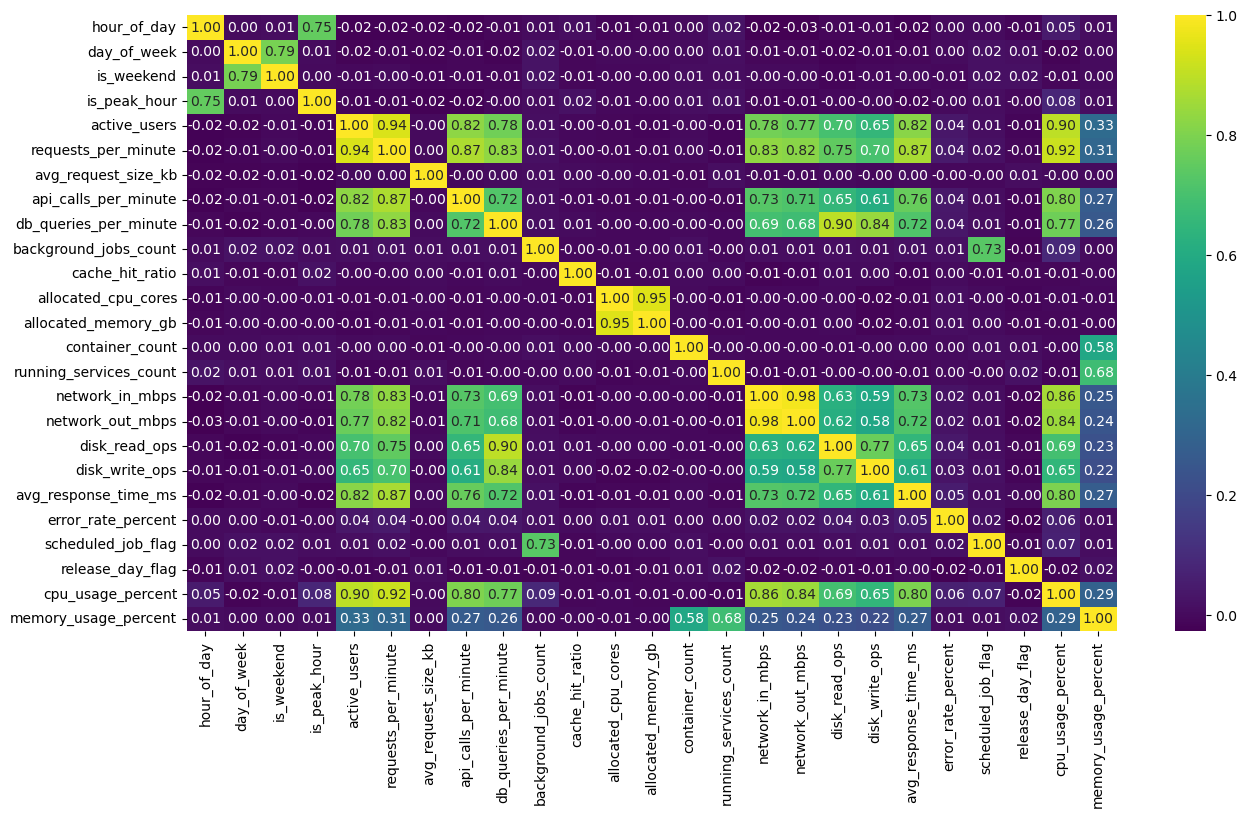

In [36]:
plt.figure(figsize=(15,8))
sns.heatmap(corr,annot=True,fmt='.2f',cmap='viridis')

- **Features Strongly Related to CPU Usage:
From the heatmap, cpu_usage_percent has strong positive correlation with:
requests_per_minute (0.92),active_users (0.90),network_in_mbps (0.86),network_out_mbps (0.84),api_calls_per_minute (0.80),avg_response_time_ms(0.80)
This means higher traffic and user activity significantly increase CPU usage.**

- **Moderate Relationships:
Some features show moderate correlation with CPU usage:
disk_read_ops (0.69),disk_write_ops (0.65)
This indicates disk operations also contribute to CPU load, but less than network and user activity.**
️
- **Weak or No Relationship:
Some features show very low correlation with CPU usage:
hour_of_day,day_of_week,cache_hit_ratio,error_rate_percent,scheduled_job_flag,release_day_flag
These variables do not significantly influence CPU usage directly.**

- **Other Strong Relationships in the Dataset:
The heatmap also shows strong correlations between other variables:
active_users- requests_per_minute (0.94),network_in_mbps - network_out_mbps (0.98),allocated_cpu_cores - allocated_memory_gb (0.95)
This indicates related infrastructure or workload variables moving together.**

# 24. Which feature has the highest correlation with CPU usage?

- **From the heatmap, cpu_usage_percent has strong positive correlation with: requests_per_minute (0.92),active_users (0.90),network_in_mbps (0.86),network_out_mbps (0.84),api_calls_per_minute (0.80),avg_response_time_ms(0.80) This means higher traffic and user activity significantly increase CPU usage.**

# 25.Are there outliers in request volume?

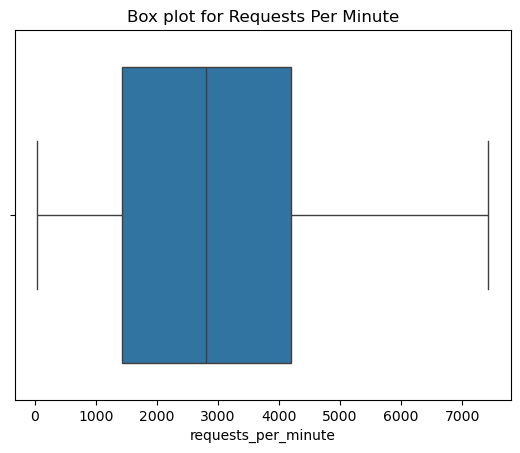

In [127]:
sns.boxplot(x=df['requests_per_minute'])
plt.title("Box plot for Requests Per Minute")
plt.show()

- **The boxplot summarizes that the distribution of Requests per minute.**
- **The center line inside the box is around 2700 per minutes .This means 50% of response times are below 2700 per minute.**

# 26.Are there outliers in response time?

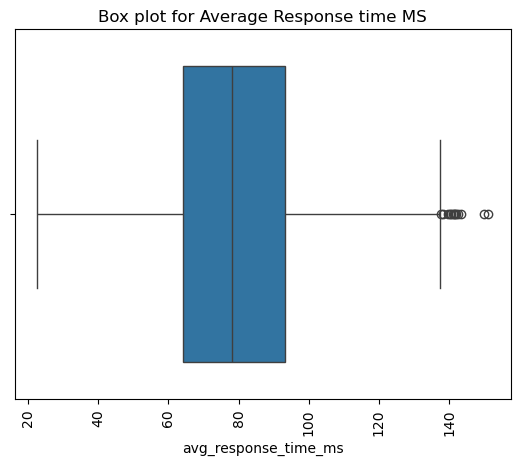

In [128]:
sns.boxplot(x=df['avg_response_time_ms'])
plt.xticks(rotation=90)
plt.title("Box plot for Average Response time MS")
plt.show()

- **The boxplot summarizes that the distribution of average response time ms.**
- **The center line inside the box is around 80 ms .This means 50% of response times are below 80 ms.**
- **The dataset shows right skewness due to high-value outliers (140–150 ms).**

# 27.Are there outliers in network traffic?

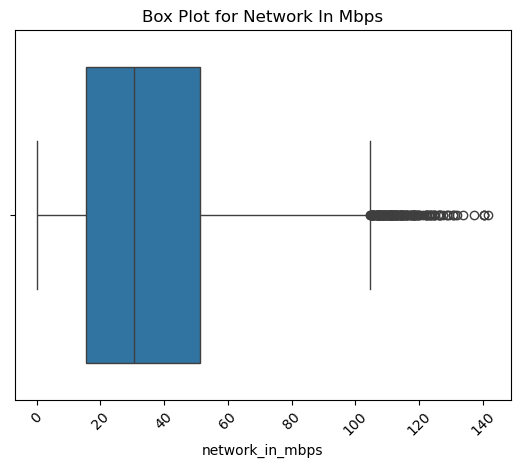

In [129]:
sns.boxplot(x='network_in_mbps',data=df)
plt.title("Box Plot for Network In Mbps")
plt.xticks(rotation=45)
plt.show()

- **The boxplot summarizes that the distribution of Network in mbps.**
- **The line inside the box is around 30 mbps .This means 30% of response times are below 30 mbps.**
- **The dataset shows right skewness due to high-value outliers (100–140).**

# 28.What is the relationship between active users and requests per minute?

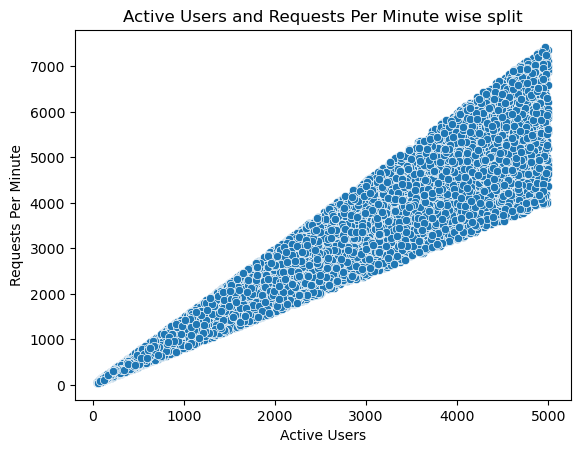

In [40]:
sns.scatterplot(x="active_users",y="requests_per_minute",data=df)
plt.title("Active Users and Requests Per Minute wise split")
plt.xlabel("Active Users")
plt.ylabel("Requests Per Minute")
plt.show()

- **The scatterplot shows the relationship between active users and cpu usage percent.**
- **It shows the clear positive relationship between this features as the active users increases requests per minute also increases.**

# 29.How does traffic vary throughout the day?

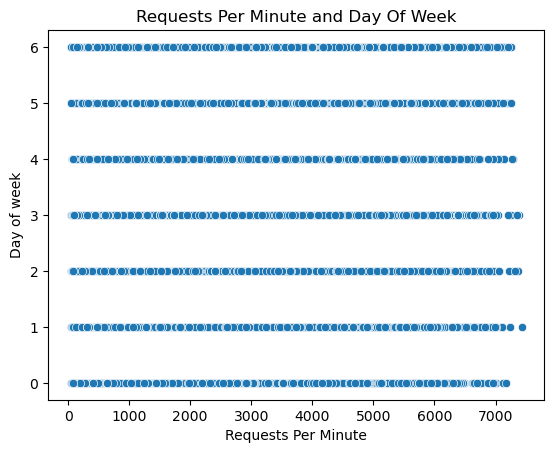

In [69]:
sns.scatterplot(x='requests_per_minute',y='day_of_week',data=df)
plt.title("Requests Per Minute and Day Of Week")
plt.xlabel("Requests Per Minute")
plt.ylabel("Day of week")
plt.show()

- **The scatterplot shows the relationship between requests per minute and day of week.**
- **It shows the clear no relationship between this features .**

# 30. Which features show non-linear relationships with CPU usage?

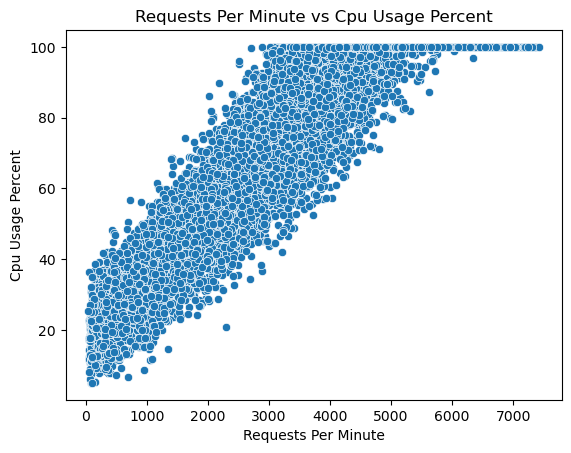

In [96]:
sns.scatterplot(x='requests_per_minute', y='cpu_usage_percent', data=df)
plt.title("Requests Per Minute vs Cpu Usage Percent")
plt.xlabel("Requests Per Minute")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between requests per minute and cpu usage percent.**
- **It shows the clear positive relationship between this features as the requests per minute increases cpu usage percent also increases.**

# 31.Is CPU usage higher when background jobs run?

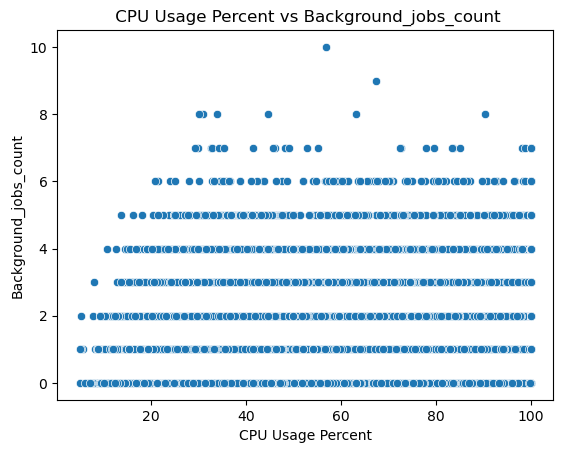

In [97]:
sns.scatterplot(x='cpu_usage_percent', y='background_jobs_count', data=df)
plt.title(" CPU Usage Percent vs Background_jobs_count")
plt.xlabel("CPU Usage Percent")
plt.ylabel("Background_jobs_count")
plt.show()

- **The scatterplot shows the relationship between  cpu usage percent and background jobs count.**
- **It shows the clear no relationship between this features.**

# 32.How does memory usage vary with container count?

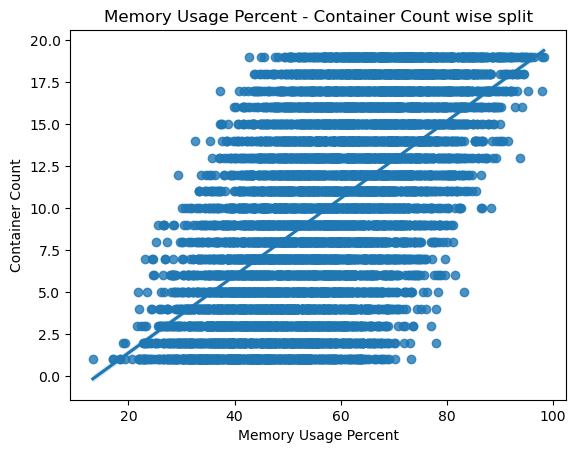

In [99]:
sns.regplot(x='memory_usage_percent', y='container_count', data=df)
plt.title("Memory Usage Percent - Container Count wise split")
plt.xlabel("Memory Usage Percent")
plt.ylabel("Container Count")
plt.show()

- **The regplot shows the positive or negative relationships between memory usage percent and container count**
- **It clearly shows the upward trend as it shares the positive relationships between memory usage percent and container count.**

# 33. Does higher service density affect CPU consumption?

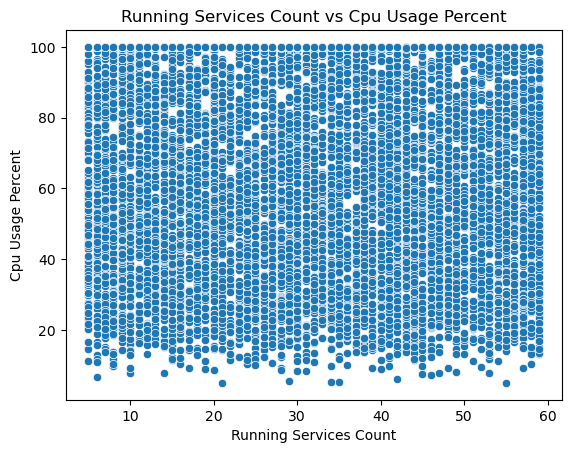

In [101]:
sns.scatterplot(x='running_services_count', y='cpu_usage_percent', data=df)
plt.title("Running Services Count vs Cpu Usage Percent")
plt.xlabel("Running Services Count")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between running services count and cpu usage percent.**
- **It shows the clear no relationship between this features .**

# 34. Are peak hours associated with higher network activity?

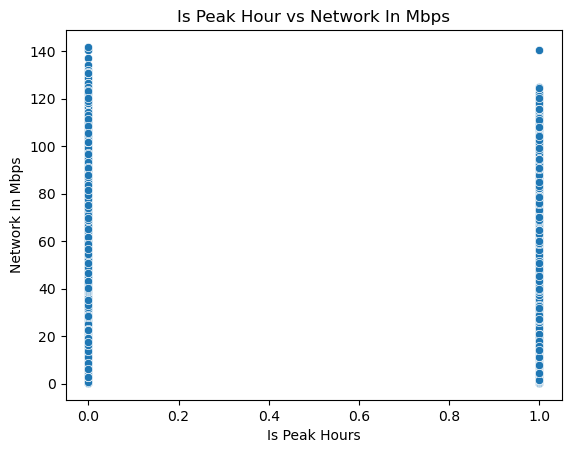

In [103]:
sns.scatterplot(x='is_peak_hour', y='network_in_mbps', data=df)
plt.title("Is Peak Hour vs Network In Mbps")
plt.xlabel("Is Peak Hours")
plt.ylabel("Network In Mbps")
plt.show()

- **The scatterplot shows the relationship between is peak hours and network in mbps.**
- **It shows the clear no relationship between this features.**

# 35.Do weekend workloads differ from weekday workloads?

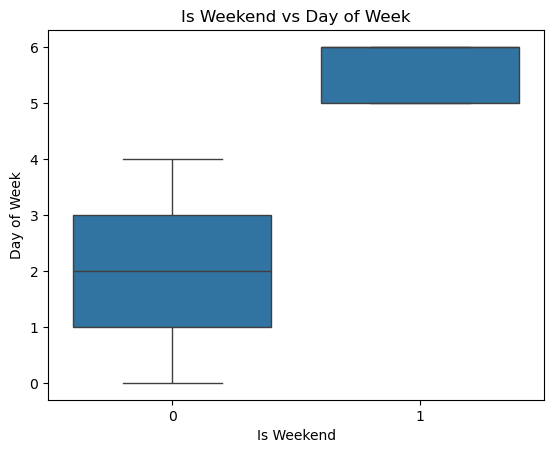

In [78]:
sns.boxplot(x='is_weekend', y='day_of_week', data=df)
plt.title("Is Weekend vs Day of Week")
plt.xlabel("Is Weekend")
plt.ylabel("Day of Week")
plt.show()

- **The boxplot summarizes that the distribution of is weekend and day of week.**
- **For Weekdays (is_weekend = 0), Values range from 0 to 4, Median = 2 Data correctly includes Monday to Friday.Distribution is spread across all weekdays.**
- **For Weekend (is_weekend = 1),Values only around 5 and 6Median ≈ 5.5 ,Very small spread Data correctly includes only. Saturday & Sunday Very less variation.**

# 36.What is the relationship between disk operations and CPU usage?

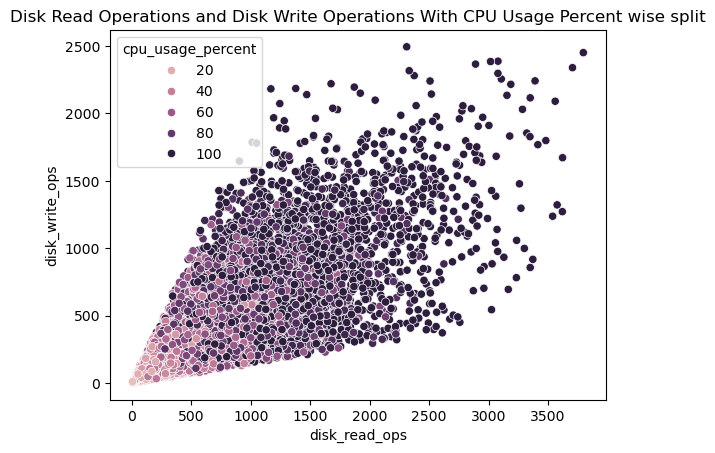

In [46]:
sns.scatterplot(x="disk_read_ops",y="disk_write_ops",hue="cpu_usage_percent",data=df)
plt.title("Disk Read Operations and Disk Write Operations With CPU Usage Percent wise split")
plt.show()

- **The scatterplot shows the relationship between disk read operations,disk write operations and cpu usage percent.**
- **It shows the clear no relationship between this features.**
- **As the disk read operations is from(0 to 500).**  

# 37. Does error rate increase with server load?

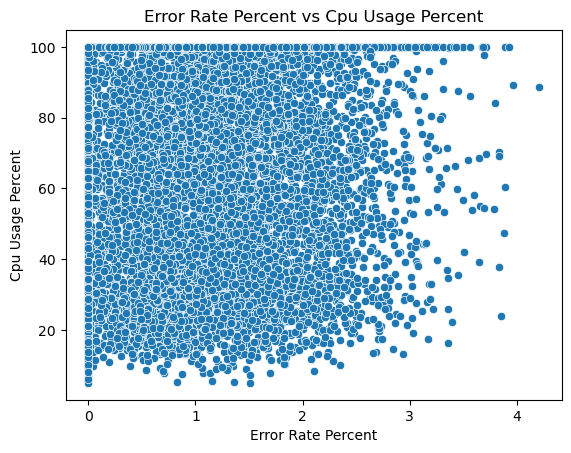

In [47]:
sns.scatterplot(x='error_rate_percent', y='cpu_usage_percent', data=df)
plt.title("Error Rate Percent vs Cpu Usage Percent")
plt.xlabel("Error Rate Percent")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between error rate percent and cpu usage percent.**
- **It shows the clear no relationship between this features .**

# 38.Do high request volumes lead to slower response times?

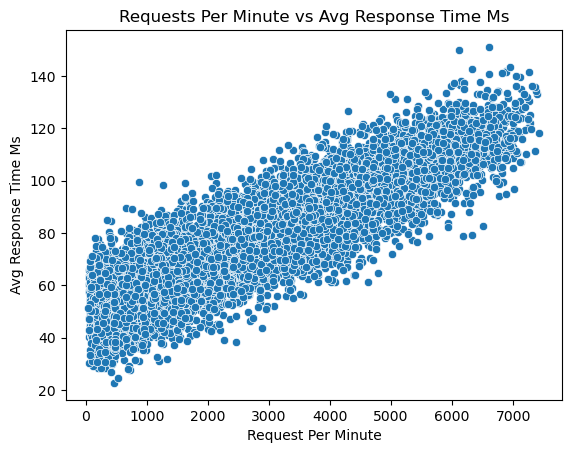

In [72]:
sns.scatterplot(x='requests_per_minute', y='avg_response_time_ms', data=df)
plt.title("Requests Per Minute vs Avg Response Time Ms")
plt.xlabel("Request Per Minute")
plt.ylabel("Avg Response Time Ms")
plt.show()

- **The scatterplot shows the relationship between disk write operations and cpu usage percent.**
- **It shows the clear positive relationship between this features as the requests per minute increases average response time ms  also increases.**

# 39.Are there clusters of high resource usage?

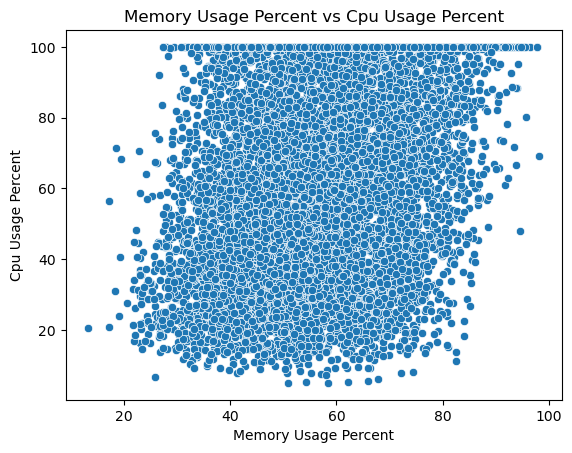

In [73]:
sns.scatterplot(x='memory_usage_percent', y='cpu_usage_percent', data=df)
plt.title("Memory Usage Percent vs Cpu Usage Percent")
plt.xlabel("Memory Usage Percent")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between memory usage percent and cpu usage percent.**
- **It shows the clear no relationship between this features.**

# 40.Which variables show the strongest multicollinearity?

- **From the heatmap, cpu_usage_percent has strong positive correlation with: requests_per_minute (0.92),active_users (0.90),network_in_mbps (0.86),network_out_mbps (0.84),api_calls_per_minute (0.80),avg_response_time_ms(0.80) This means higher traffic and user activity significantly increase CPU usage.**

# 41 .Does network output correlate with network input?

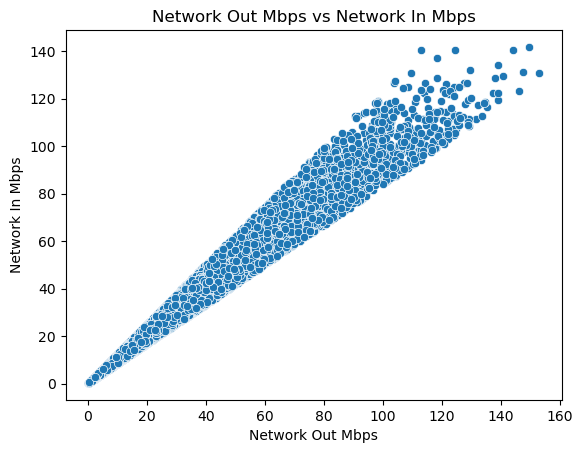

In [49]:
sns.scatterplot(x='network_out_mbps', y='network_in_mbps', data=df)
plt.title("Network Out Mbps vs Network In Mbps")
plt.xlabel("Network Out Mbps")
plt.ylabel("Network In Mbps")
plt.show()

- **The scatterplot shows the relationship between network out mbps and network in mbps.**
- **It shows the clear positive relationship between this features.**

# 42.Does server load increase with API calls?

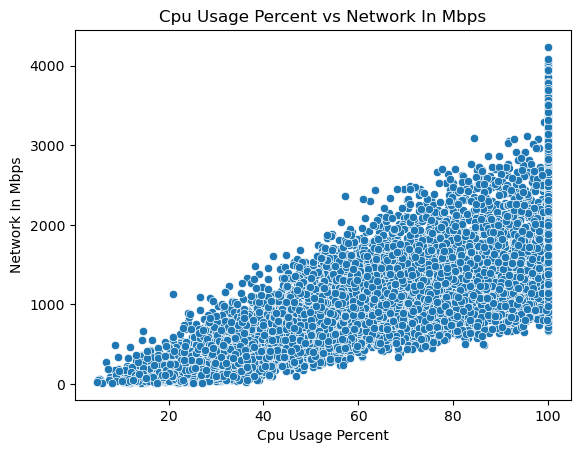

In [76]:
sns.scatterplot(x='cpu_usage_percent', y='api_calls_per_minute', data=df)
plt.title("Cpu Usage Percent vs Network In Mbps")
plt.xlabel("Cpu Usage Percent")
plt.ylabel("Network In Mbps")
plt.show()

- **The scatterplot shows the relationship between cpu usage percent and network in mbps.**
- **It shows the clear positive relationship between this features as the cpu usage percent increases network in mbps also increases.**

# 43.What patterns exist in CPU usage over time?

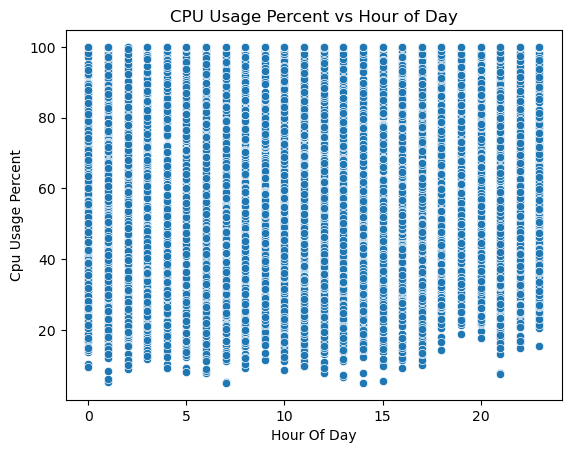

In [104]:
sns.scatterplot(x='hour_of_day', y='cpu_usage_percent', data=df)
plt.title("CPU Usage Percent vs Hour of Day")
plt.xlabel("Hour Of Day")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between hour of day and cpu usage percent.**
- **It shows the clear no relationship between this features.***

# 44. Are there threshold levels after which CPU spikes rapidly?

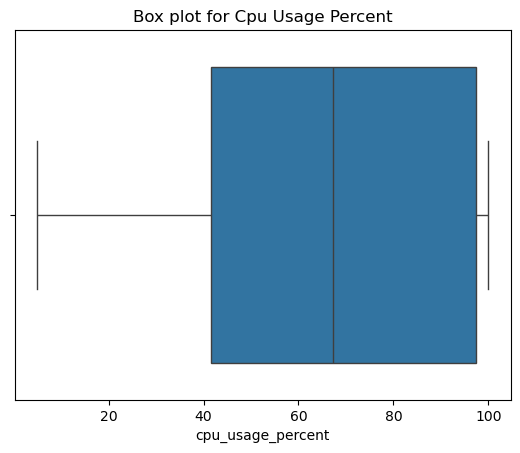

In [106]:
sns.boxplot(x=df['cpu_usage_percent'])
plt.title("Box plot for Cpu Usage Percent")
plt.show()

- **The boxplot summarizes that the distribution of CPU Usage percent.**
- **The median CPU usage is around 65–70%, meaning half of the observations are above this value and half are below.**
- **The interquartile range (IQR) appears to be roughly between 40% and 95%, showing that most CPU usage values fall within this range.**
- **The minimum CPU usage is around 5–10%, while the maximum reaches close to 100%.**
- **There are no outliers visible.**

# 45.Which features explain most of the variance in CPU usage?

- **From the heatmap, cpu_usage_percent has strong positive correlation with: requests_per_minute (0.92),active_users (0.90),network_in_mbps (0.86),network_out_mbps (0.84),api_calls_per_minute (0.80),avg_response_time_ms(0.80) This means higher traffic and user activity significantly increase CPU usage.**

# 46.Are there sudden workload spikes in the dataset?

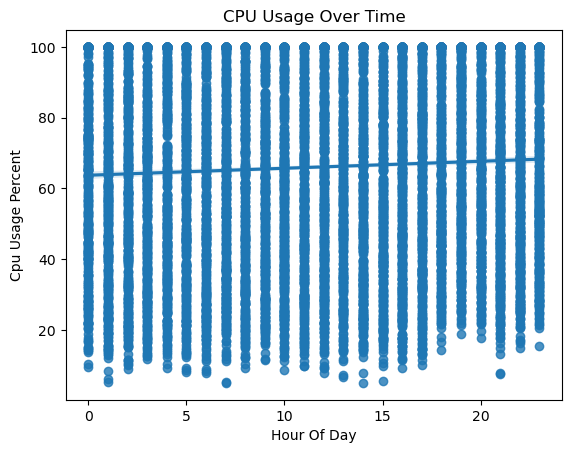

In [108]:
sns.regplot(x='hour_of_day', y='cpu_usage_percent', data=df)
plt.title("CPU Usage Over Time")
plt.xlabel("Hour Of Day")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The reg plot the relationship between hour of day and cpu usage percent.**
- **It clearly shows that the upward trend which means its shares the positive relationship between these features hour of day and cpu usage percent.**

# 47. Does disk activity increase during peak hours?

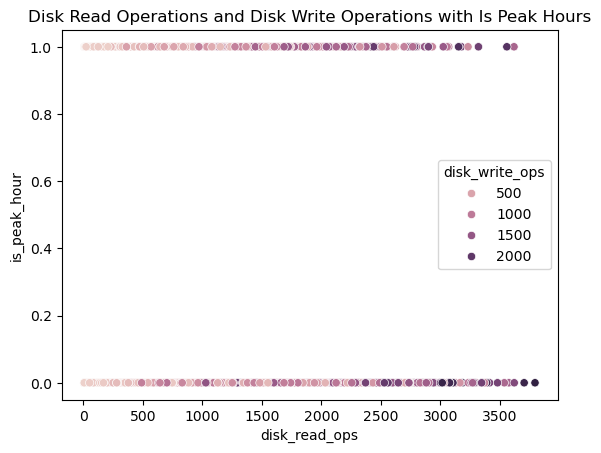

In [93]:
sns.scatterplot(x='disk_read_ops', y='is_peak_hour',hue="disk_write_ops", data=df)
plt.title("Disk Read Operations and Disk Write Operations with Is Peak Hours")
plt.show()

- **The scatterplot shows the relationship between disk write operations,disk read operations and is peak hour.**
- **It clearly shows that there is no relationship between these features.**

# 48.Does response time increase when CPU usage exceeds 80%?

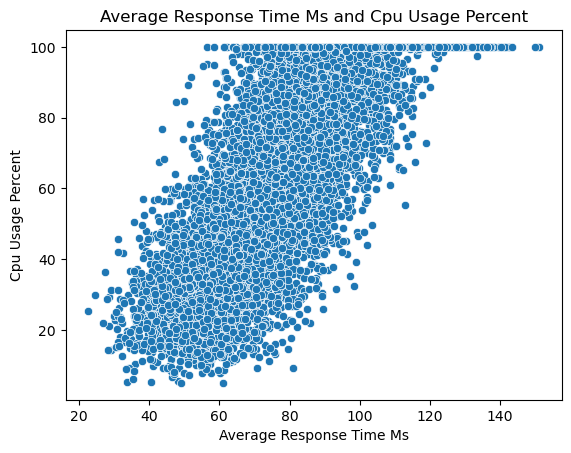

In [53]:
sns.scatterplot(x='avg_response_time_ms', y='cpu_usage_percent', data=df)
plt.title("Average Response Time Ms and Cpu Usage Percent")
plt.xlabel("Average Response Time Ms")
plt.ylabel("Cpu Usage Percent")
plt.show()

- **The scatterplot shows the relationship between average response time ms and cpu usage percent.**
- **It clearly shows the positive relationship between this features as the avreage response time ms increases cpu usage percent.**

# 49.Which feature combinations produce the highest load?

**Requests Per Minute and Active Users with cpu usage are produce the highest load.**

# 50. What operational conditions lead to extreme server utilization?

- **Extreme server utilization occurs when there is high incoming demand and processing workload, specifically:**
- **High number of requests per minute and active users.**
- **Increased network traffic (incoming and outgoing).**
- **High API calls and database queries.**
- **Increased disk I/O operations.**
- **These conditions collectively increase computational workload, leading to very high CPU usage.**

## Step 4:Feature Scaling 

In [8]:
df1 = df.copy()

In [12]:
y = df['cpu_usage_percent']
X = df.drop(columns=['cpu_usage_percent'])

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [14]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Step 5:Model Building and Evaluation

## *Linear Regression*

In [16]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

print("MAE:", mae_lr)
print("RMSE:", rmse_lr)
print("R2 Score:", r2_lr)

MAE: 6.877173910399426
RMSE: 78.59598717280335
R2 Score: 0.8984390220059942


- **The Linear Regression model achieved a Mean Absolute Error (MAE) of approximately 6.87, indicating that the predicted cpu usage percent deviates from the actual values by about 6 units on average.** 
- **The Root Mean Squared Error (RMSE) is 78.59, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.89 indicates that the model explains around 89% of the variance in the cpu usage percent.**
- **Overall, the model provides moderate performance but may not fully capture complex, non-linear relationships in the data.**

## *Random Forest Regressor*

In [19]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

print("MAE:", mae_rf)
print("RMSE:", rmse_rf)
print("R2 Score:", r2_rf)

MAE: 3.388174680456139
RMSE: 22.38070368518703
R2 Score: 0.9710798701533686


- **The Random Forest Regressor model achieved a Mean Absolute Error (MAE) of approximately 3.38, indicating that the predicted engagement_score deviates from the actual values by about 3 units on average.** 
- **The Root Mean Squared Error (RMSE) is 22.38, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.97 indicates that the model explains around 97% of the variance in the engagement_score.**
- **Overall, the model provides high performance capturing relationships in the data.**

## *Decision Tree Regressor*

In [20]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
mae_dt = mean_absolute_error(y_test, y_pred_dt)
rmse_dt = mean_squared_error(y_test, y_pred_dt)
r2_dt = r2_score(y_test, y_pred_dt)

print("MAE:", mae_dt)
print("RMSE:", rmse_dt)
print("R2 Score:", r2_dt)

MAE: 4.823257072523271
RMSE: 47.74192916714342
R2 Score: 0.9383083387339469


- **The Decision Tree Regressor model achieved a Mean Absolute Error (MAE) of approximately 4.82, indicating that the predicted engagement_score deviates from the actual values by about 4 units on average.** 
- **The Root Mean Squared Error (RMSE) is 47.74, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.93 indicates that the model explains around 93% of the variance in the engagement_score.**
- **Overall, the model provides high performance capture relationships in the data.**

## *Polynomial Features*

In [21]:
from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2)
X_train_poly = poly.fit_transform(X_train_scaled)
X_test_poly = poly.transform(X_test_scaled)
lr_poly = LinearRegression()
lr_poly.fit(X_train_poly, y_train)
y_pred_poly = lr_poly.predict(X_test_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
rmse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)

print("MAE:", mae_poly)
print("RMSE:", rmse_poly)
print("R2 Score:", r2_poly)

MAE: 4.4701043348696965
RMSE: 31.029940312128627
R2 Score: 0.9599034098488186


- **Interpretations**
- **The Polynomial Regression model (degree 2) was used to capture non-linear relationships between features and engagement_score.**
- **The model achieved a Mean Absolute Error (MAE) of approximately (your MAE) and an RMSE of (your RMSE), indicating that the prediction errors are relatively low.**
- **The R² score of (your R²) shows the proportion of variance explained by the model.**
- **Compared to Linear Regression, Polynomial Regression is able to capture more complex patterns in the data, potentially improving model performance.**

## *Gradient Boosting Regressor*

In [22]:
from sklearn.ensemble import GradientBoostingRegressor

gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)
y_pred_gbr = gbr.predict(X_test)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
rmse_gbr = mean_squared_error(y_test, y_pred_gbr)
r2_gbr = r2_score(y_test, y_pred_gbr)

print("MAE:", mae_gbr)
print("RMSE:", rmse_gbr)
print("R2 Score:", r2_gbr)

MAE: 3.4809155409225605
RMSE: 21.93082731629045
R2 Score: 0.9716611960663707


- **The Gradient Boosting Regressor model achieved a Mean Absolute Error (MAE) of approximately 3.48, indicating that the predicted engagement_score deviates from the actual values by about 3 units on average.** 
- **The Root Mean Squared Error (RMSE) is 21.93, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.97 indicates that the model explains around 97% of the variance in the engagement_score.**
- **Overall, the model provides high performance capturing relationships in the data.**

## KNeighbors Regressor

In [23]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)
y_pred_knn = knn.predict(X_test_scaled)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
rmse_knn = mean_squared_error(y_test, y_pred_knn)
r2_knn = r2_score(y_test, y_pred_knn)

print("MAE:", mae_knn)
print("RMSE:", rmse_knn)
print("R2 Score:", r2_knn)

MAE: 5.851929185174748
RMSE: 63.01076353840778
R2 Score: 0.9185780979499658


- **The K Neighbors Regressor model achieved a Mean Absolute Error (MAE) of approximately 5.85, indicating that the predicted engagement_score deviates from the actual values by about 5 units on average.** 
- **The Root Mean Squared Error (RMSE) is 63.01, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.91 indicates that the model explains around 91% of the variance in the engagement_score.**
- **Overall, the model provides high performance capturing relationships in the data.**

## XGBoost Regressor

In [25]:
from xgboost import XGBRegressor

xgb = XGBRegressor(random_state=42)
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)

mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = mean_squared_error(y_test, y_pred_xgb)
r2_xgb = r2_score(y_test, y_pred_xgb)

print("MAE:", mae_xgb)
print("RMSE:", rmse_xgb)
print("R2 Score:", r2_xgb)

MAE: 3.6181574732808373
RMSE: 24.299331160902444
R2 Score: 0.9686006381995615


- **The XGB Regressor model achieved a Mean Absolute Error (MAE) of approximately 3.61, indicating that the predicted engagement_score deviates from the actual values by about 3 units on average.** 
- **The Root Mean Squared Error (RMSE) is 24.29, which is slightly higher than MAE, suggesting that the model has some larger errors but overall remains stable.** 
- **The R² score of 0.96 indicates that the model explains around 96% of the variance in the engagement_score.**
- **Overall, the model provides high performance capturing relationships in the data.**

## Step 6:Business Insights

- *Peak hours generate higher CPU and memory usage.*

- *Increased user activity leads to higher server resource consumption.*

- *Response time and error rates may rise during heavy workloads.*
    
- *Resource forecasting helps prevent system downtime.*
    
- *Efficient resource allocation reduces operational costs.*